In [2]:
import os

# Preparing data for fire impact analysis

This notebook demonstrates the process for processing input data for use with the fire impacts library.

The process is largely automated and, in many cases, the data is downloaded automatically from the publisher.

There are a few things that you will need, however:

* A catchment boundary for your area of interest (eg Shapefile, GeoJSON)
* The date of a fire event within the catchment,
* Several other datasets that you will need to manually download and store locally


## Installation

You will need Python with a set of scientific libraries installed, plus the `fire_impacts` package itself. There are two ways to set up the environment, described below. **Method 1 is recommended** — it creates a fully self-contained environment and is less likely to run into conflicts.

#### A note on environments

A Python *environment* is an isolated copy of Python with its own set of installed libraries. Using an environment means the packages needed for this project won't interfere with anything else on your computer. The instructions below use [Miniforge](https://github.com/conda-forge/miniforge), a lightweight tool for managing Python environments in scientific work. If you don't already have it installed, download and install Miniforge first. Miniforge includes `mamba`, a faster drop-in replacement for the `conda` command that is recommended for resolving complex environments like this one.


### Method 1 — Create a new environment from `environment.yml` (recommended)

The file `environment.yml` in this repository describes a complete Python environment: the Python version, all required libraries, and their versions. Mamba will create this environment for you in one step.

Open a **Miniforge Prompt** (Windows) or terminal (Mac/Linux), navigate to the folder containing this repository, and run:

```
mamba env create -f environment.yml
```

This will take a few minutes. When it finishes, activate the new environment:

```
conda activate bushfire-py313
```

You will need to activate the environment each time you open a new terminal or Miniforge Prompt before working with this project.

> **Note:** `environment.yml` includes a patched version of the `pysheds` library (installed directly from GitHub) to fix a compatibility issue with NumPy 2.0. It also installs `dea-tools`, which requires the PostgreSQL development headers (`pg_config`) to be available on your system. On Windows this is usually satisfied automatically via conda-forge; if the install fails at that step, see the [dea-tools documentation](https://github.com/GeoscienceAustralia/dea-notebooks).


### Method 2 — Install into an existing Python environment using `requirements.txt`

Use this method if you already have a working scientific Python installation (with `numpy`, `pandas`, `matplotlib`, and `jupyter`) and want to add the project's extra dependencies to it.

A `requirements.txt` file is a plain text list of Python packages. The `pip` tool reads this file and installs each one.

Open a Miniforge Prompt or terminal, activate your existing environment if you have one, navigate to the folder containing this repository, and run:

```
pip install -r requirements.txt
```

> **Note:** `requirements.txt` installs the standard `pysheds` release from PyPI. If you encounter errors related to `pysheds` and NumPy, install the patched version manually:
> ```
> pip install https://github.com/joelrahman/pysheds/archive/refs/heads/master.zip
> ```


### Installing the `fire_impacts` package itself

Whichever method you used above, the final step is the same: install the `fire_impacts` library from your local copy of the repository. The `-e` flag installs it in *editable* mode, meaning any changes to the source code take effect immediately without reinstalling.

From the repository folder, run:

```
pip install -e .
```


#### Checking the installation

When the installation is complete, all the following imports should run without error.

In [3]:
from fire_impacts import FireImpactsProject
from fire_impacts.pre import project, topography, severity, soil, rusle

## Logging

We use logging statements to provide feedback on progress through various steps. This allows you to tailor what level of information you see by setting a log 'level':

* `DEBUG`: Low level information about progress
* `INFO`: General progress updates
* `WARNING`: Problems or potential problems that the system can handle
* `EROR`: Problems that prevent the system from running correctly

When you set a log level, you will see those messages as well as the more serious ones. So if you choose `INFO`, you will also see `WARNING` and `ERROR` messages. If you choose `WARNING`, you will also see `ERROR`.

In [4]:
import logging
logging.basicConfig(level=logging.INFO,format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')

## Projects

We organise all the data related to a study in a project directory. This should generally be a *new* directory that will be populated with data that has been computed with the library. The library will manage the subdirectories and data within the main project directory.

In Python, we use a `FireImpactsProject` object to represent this directory and all the data stored within it

Here, we create a new project in the current directory. **Note:** In this case we will delete (`clear`) any existing data in that directory.

By default, *current directory* here is the directory this Notebook is saved in.

> **Access Note:** running this Notebook and associated code from a OneDrive folder may result in 'Access Denied' errors when creating or updating a project. We recommend setting up on your C:\ (or other primary local) drive.

In [5]:
proj = FireImpactsProject('.\\fire_impacts_example_project', clear=True)
# proj = FireImpactsProject('\\zz_TempDump\\fire_impacts_example_project',clear=True)

2026-04-16 19:01:46,476 - fire_impacts.pre.project - INFO - Clearing existing project folder: \zz_TempDump\fire_impacts_example_project


## Catchment areas

A project can store data related to one or more catchments.

Catchments are added to the project by providing a boundary coverage (eg a Shapefile or a GeoJSON file).

Here, we add a small example catchment, from the `test_data` directory, but you can use your own.

**Note:** The boundary coverage should include a coordinate reference system (CRS). This is the CRS that will be used for all other data stored in relation to this catchment in the project.

In [6]:
example_catchment_name = 'EgSmallCatchment_7899'
proj.add_catchment(f'..\\test_data\\{example_catchment_name}.shp')

In [7]:
proj.catchments

['EgSmallCatchment_7899']

## Pre-processing steps

We will now work through each step of data pre-processing to support for the fire impacts modelling:

* **Topography**: Determine various topographic properties from a DEM, including headwater catchments used to model debris flow triggers
* **Fire severity**: Analyse satellite information to determine the intensity of a historical fire event
* **Soils**: Extract relevant soil properties from the Soil and Landscape Grid of Australia
* **RUSLE**: Compute RUSLE terms (K, L, S and C), including fire modified versions of K and C

There is some flexibility to run these processes in different orders, except that the RUSLE processing should be done _after_ other processes.

The following sections describe each process and the data required.

## Aside: Visualising data

The `proj` object includes convenience functions for visualising the processed data layers as they are created. Here, we show the visualisation after each step using built-in default parameters.

## Topography

The topographic processing uses a DEM to identify relevant topographic properties required for the modelling.. 

This includes:

* Headwater catchment delineation, used to model the areas likely to trigger debris flow, and
* Slope and hillslope length, used in the parameterisation of erosion modelling.

### Digital Elevation Model (DEM)
By default, the package will download the Geoscience Australia hydrologically-enforced DEM ([national 1" DEM](https://ecat.ga.gov.au/geonetwork/srv/eng/catalog.search#/metadata/72759)), which has a horizontal spatial resolution of 1 arc second (approx. 30 metres).

> **Option**: If you have a specific DEM you wish to use, you can provide the path\filename.ext as the second argument of `topography.extract_catchment_dems()`. Make sure the DEM covers the entire catchment area.


2026-04-16 19:03:07,392 - fire_impacts.pre.topography - INFO - Extracting 1 catchment DEMs
2026-04-16 19:03:07,394 - fire_impacts.pre.topography - INFO - Extracting DEM for catchment: EgSmallCatchment_7899
2026-04-16 19:03:07,396 - fire_impacts.pre.topography - INFO - No DEM path provided, downloading DEMH data from AWS for catchment: EgSmallCatchment_7899
C:\Users\richard.farr\OneDrive - Alluvium Consulting Australia\Documents\WorkItems\Projects\0124114_Bushfire_WQ_Modelling\WaterRA_Bushfire_Modeling\fire_impacts\pre\util.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  catchment = catchment.to_crs(raster_crs).buffer(raster_res[0]*2)
2026-04-16 19:03:15,950 - fire_impacts.pre.util - INFO - Reprojecting raster from EPSG:4326 to EPSG:7899
2026-04-16 19:03:16,012 - rasterio._env - WARNING - CPLE_NotSupported in driver GTiff does not support creati

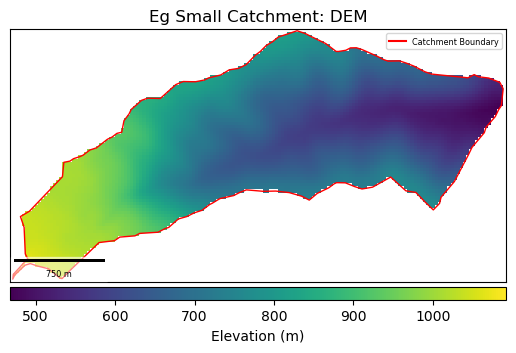

In [8]:
# If you have a specific DEM you want to use, point python to it. 
#We have a DEM for the example catchment included in the test date for this package.
optional_DEM_filename = '..\\test_data\\example_dem.tif'
# Get a DEM. To use your own DEM, replace None with the filename path:
topography.extract_catchment_dems(proj,None)
# Visualise the processed DEM:
proj.plot_catchment_raster('Topography','DEM.tif')

### Headwaters
This package will automatically derive headwaters from the DEM.

In [9]:
# Just call the extract_headwaters() method from the topography module:
headwaters = topography.extract_headwaters(proj)

2026-04-16 19:03:27,545 - fire_impacts.pre.project - INFO - Processing 1 catchments
2026-04-16 19:03:27,547 - fire_impacts.pre.topography - INFO - Extracting headwaters for catchment: EgSmallCatchment_7899
2026-04-16 19:03:27,570 - fire_impacts.pre.topography - INFO - Saved raster to \zz_TempDump\fire_impacts_example_project\Catchments\EgSmallCatchment_7899\Topography\Slope.tif
2026-04-16 19:03:27,579 - fire_impacts.pre.topography - INFO - Creating hydrologically-enforced DEM from \zz_TempDump\fire_impacts_example_project\Catchments\EgSmallCatchment_7899\Topography\DEM.tif
2026-04-16 19:03:27,588 - fire_impacts.pre.topography - INFO - Filling pits
2026-04-16 19:03:27,594 - fire_impacts.pre.topography - INFO - Filling depressions
2026-04-16 19:03:27,636 - fire_impacts.pre.topography - INFO - Resolving flats
2026-04-16 19:03:27,861 - fire_impacts.pre.topography - INFO - Computing flow direction
2026-04-16 19:03:27,891 - fire_impacts.pre.topography - INFO - Saved raster to \zz_TempDump\fi

Headwaters can be visualised straightaway as a map using `FireImpactsProject.plot_headwaters()`. You can also view a quick summary of the headwaters in table form using the built-in `.head()` method.

,hw_ID,Area_m2,Area_ha,PP_Flow_acc,PourPt_X,PourPt_Y,Dist,Move_dist,X_EndP,Y_EndP
0,1,20259.0,2.0,31.0,2.616468e+06,2.418234e+06,571.6,604.8,2.616570e+06,2.417672e+06
1,2,20913.0,2.1,32.0,2.615752e+06,2.418183e+06,105.4,112.8,2.615855e+06,2.418209e+06
2,3,17645.0,1.8,27.0,2.616570e+06,2.418107e+06,409.8,419.6,2.616596e+06,2.417672e+06
3,4,18952.0,1.9,29.0,2.616903e+06,2.418107e+06,333.3,342.9,2.616954e+06,2.417749e+06
4,5,20913.0,2.1,32.0,2.616059e+06,2.418004e+06,355.1,380.9,2.616238e+06,2.417698e+06


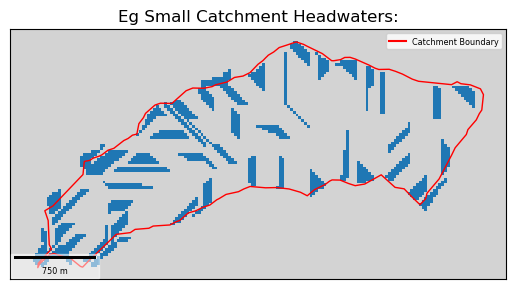

In [10]:
# Plot the raw headwaters to see what they look like:
proj.plot_headwaters(example_catchment_name)

# See a snapshot of what they look like in tabular form:
headwaters[example_catchment_name].head()

### Slope
A slope layer is calculated when the headwaters are defined. You can view it easily:

2026-04-16 19:03:56,525 - fire_impacts.pre.project - INFO - Processing 1 catchments


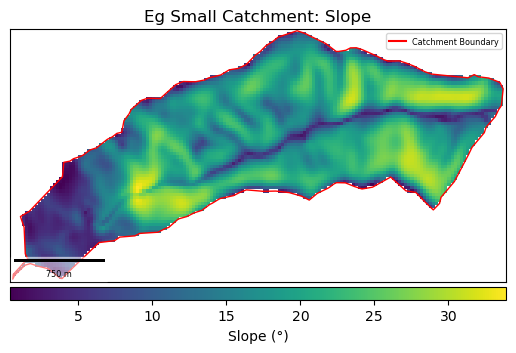

In [11]:
# View the slope raster which was derived from the DEM:
proj.plot_catchment_raster('Topography','Slope')

### Flow Accumulation
Similarly, hydrology rasters such as flow accumulation are also saved and can be viewed in the same way:

2026-04-16 19:04:07,645 - fire_impacts.pre.project - INFO - Processing 1 catchments


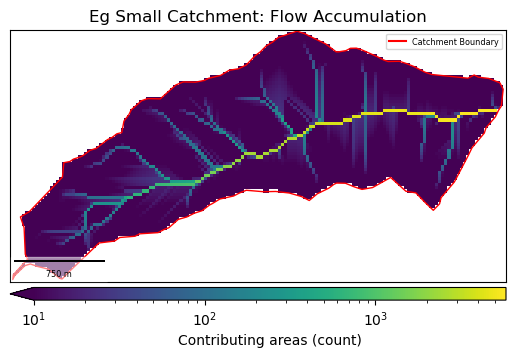

In [12]:
proj.plot_catchment_raster('Topography','Flow_accumulation')

## Aside: Function documentation

Most of the library functions include documentation describing the process, the function parameters and any return values

You can access the help in Jupyter with the `?` operator, for example:

```
topography.extract_headwaters?
```

In [13]:
topography.extract_headwaters?

Signature:
topography.extract_headwaters(
    project: fire_impacts.pre.project.FireImpactsProject,
    name: str | None = None,
    threshold_m2: float = 20000,
)
Docstring:
Delinate headwaters for a catchment based on a flow accumulation 
threshold.

Parameters:
- project (FireImpactsProject): project object for directory 
structure
- name (str): Name of the catchment to process. If None, process 
all catchments.
- threshold_m2 (float): Threshold area in square meters for 
headwaters. Default is 20,000 m^2.

Returns:
- Dataframe containing headwater summary data

Writes:
- Headwaters.shp: Shapefile containing the headwaters polygons.
- Headwaters.tif: Raster file containing the headwaters polygons.
- Headwaters.csv: CSV file containing the headwaters summary
- Flow_accumulation.tif: Raster file containing the flow 
accumulation data.
- Stream_Network.tif: Raster file containing the stream network 
data.
- Slope.tif: Raster file containing the slope data.
-----------------------------

## Fire Severity
Fire severity data requires measuring Normalised Burn Ration (NBR) before and after a fire, to produce a measure of change called delta-NBR (abbreviated as dNBR or ΔNBR).

This package automatically finds and downloads relevant satellite-based NBR datasets and computes fire severity for your catchment. 
> **Note**: The fire start and end dates here correspond to an actual fire that took place in this area.

In [14]:
fire_start_date = '2019-01-15'  # Set fire start date (the date that fire started)
fire_end_date = '2019-03-07'    # Set fire end date (the date that fire ended)

In [15]:
# This method may take a few minutes to download and process data.
severity.calculate_fire_severity(
    project=proj,
    catchment=None,
    fire_start_date=fire_start_date,
    fire_end_date=fire_end_date,
)

2026-04-16 19:04:30,230 - fire_impacts.pre.project - INFO - Processing 1 catchments
2026-04-16 19:04:30,431 - fire_impacts.pre.severity - INFO - No start date for pre-fire data provided. Defaulting to 90 days before fire start date.
2026-04-16 19:04:30,432 - fire_impacts.pre.severity - INFO - No end date for post-fire data provided. Defaulting to 90 days after fire end date.
2026-04-16 19:04:30,433 - fire_impacts.pre.severity - INFO - Bounding box not provided. Calculating bounding box from shapefile with 10km buffer.
2026-04-16 19:04:30,507 - fire_impacts.pre.severity - INFO - Calculating Pre_fire NBR for EgSmallCatchment_7899
2026-04-16 19:04:30,508 - fire_impacts.pre.severity - INFO - calc_nbr(): loading sentinel data for Prefire (2018-10-17 to 2019-01-14)
2026-04-16 19:04:30,658 - fire_impacts.pre.severity - INFO - Found 5 sentinel datasets for Prefire
2026-04-16 19:04:48,589 - fire_impacts.pre.severity - INFO - About to call write_raster_xarray() for pre-fire...
2026-04-16 19:04:4

{'EgSmallCatchment_7899': None}

2026-04-16 19:05:12,328 - fire_impacts.pre.project - INFO - Processing 1 catchments


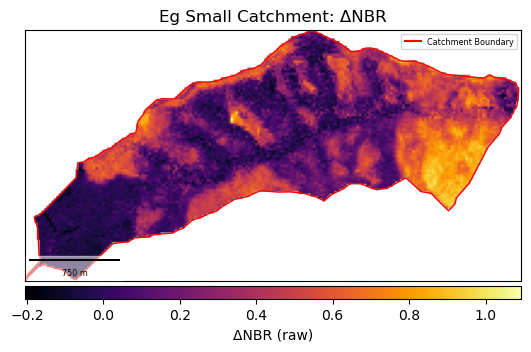

In [16]:
proj.plot_catchment_raster('FireSeverity', 'dNBR')

## Soils
Soil data are required for RUSLE (erosion) and debris flow simulations.

### Required Inputs
Many of these will be downloaded and processed automatically by the package, but you will need a **TERN API KEY** to access them. The following instructions show you how to obtain an API and save it on Windows in such a way that python will be able to access it:
1. Create a TERN account - [Instructions for creating a TERN account (TERN Youtube channel)](https://youtu.be/HTlc0xk4zf8?si=z_vEqToQDwnK4-KI)
2. Generate an API key - [Generating an API key](https://youtu.be/HTlc0xk4zf8?si=z_vEqToQDwnK4-KI)
3. Save the full API key as a user-level environment variable:
   1. *System Properties > Advanced > Environment Variables > User variables > New*
   2. *Variable name*: `'TERN_API_KEY'` or similar
   3. *Variable value*: Paste the full API key here
   4. *OK*
5. Use `os.environ.get()` with your variable name so python can see what it is, without having to store the key itself in this notebook.

You will also need an **Aridity raster** file, which is included for the example catchment but will need to be obtained for your catchment of interest before loading the subsequent datasets or running the simulations.

In [17]:
# Tell python where your API key is:
API_KEY = os.environ.get('TERN_API_KEY')
# Download the relevant data from TERN:
soil.download_soil_data_stac(proj, api_key=API_KEY)

# Existing aridity raster location:
ARIDITY=r'..\\test_data\\AridityPT_EgSmallCatchment_7899.tif'
# Extract aridity data for each catchment:
soil.extract_aridity_data(proj, aridity_raster=ARIDITY)

2026-04-16 19:05:29,149 - fire_impacts.pre.project - INFO - Processing 1 catchments
2026-04-16 19:05:55,344 - urllib3.connectionpool - WARNING - Retrying (Retry(total=4, connect=None, read=None, redirect=None, status=None)) after connection broken by 'ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x000002C53B7BA870>, 'Connection to data.tern.org.au timed out. (connect timeout=None)')': /model-derived/slga/NationalMaps/SoilAndLandscapeGrid/SOC/catalog.json
2026-04-16 19:06:49,972 - fire_impacts.pre.soil - INFO - Processing catchment: EgSmallCatchment_7899 with 12 grids found
2026-04-16 19:06:49,974 - fire_impacts.pre.soil - INFO - Using GDAL API key from temporary file C:\Users\RICHAR~1.FAR\AppData\Local\Temp\tmp7w94kt5dgdal_api_key.txt
2026-04-16 19:06:49,975 - fire_impacts.pre.soil - INFO - Downloading BDW_000_005_EV_N_P_AU_TRN_N_20230607
C:\Users\richard.farr\OneDrive - Alluvium Consulting Australia\Documents\WorkItems\Projects\0124114_Bushfire_WQ_Modelling\WaterR

2026-04-16 19:07:47,317 - fire_impacts.pre.project - INFO - Processing 1 catchments


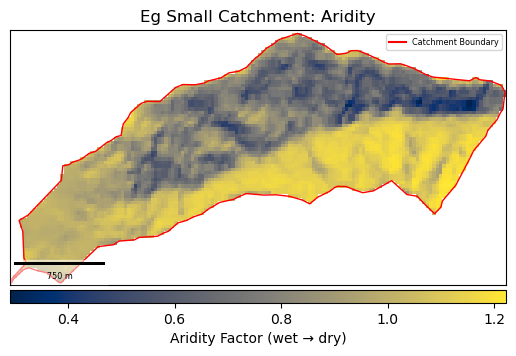

In [18]:
# Visualise the processed aridity raster:
proj.plot_catchment_raster('Soils', 'Aridity')

## RUSLE
The **R**evised **U**niversal **S**oil **L**oss **E**quation is used to estimate general post-fire erosion and is calculated for the entire catchment.

### Required Inputs
You will need to obtain RUSLE factor rasters for the erosion simulations. The package will prepare them for simulation in each catchment. 
Both **C-factor** and **K-factor** rasters are required. They have been provided for this example catchment to demonstrate functionality.


### C- and K-Factors

In [19]:
# Point to your provided rasters:
c_factor_path='..\\test_data\\Soil_RusleFactor_C_EgSmallCatchment_7899.tif'
k_factor_path='..\\test_data\\Soil_RusleFactor_K_EgSmallCatchment_7899.tif'

# Compute adjusted K- and C-factors ready for erosion simulation:
rusle.compute_adjusted_k_c(proj, catchment=example_catchment_name, c_factor_fn=c_factor_path, k_factor_fn=k_factor_path)

2026-04-16 19:07:56,099 - fire_impacts.pre.util - INFO - Reprojecting raster from EPSG:7899 to EPSG:7899
2026-04-16 19:07:56,103 - rasterio._env - WARNING - CPLE_NotSupported in driver GTiff does not support creation option RES
2026-04-16 19:07:56,114 - fire_impacts.pre.util - INFO - Reprojecting clipped raster to: \zz_TempDump\fire_impacts_example_project\Catchments\EgSmallCatchment_7899\Erodibility\C_factor.tif
2026-04-16 19:07:56,161 - fire_impacts.pre.util - INFO - Reprojecting raster from EPSG:7899 to EPSG:7899
2026-04-16 19:07:56,164 - rasterio._env - WARNING - CPLE_NotSupported in driver GTiff does not support creation option RES
2026-04-16 19:07:56,170 - fire_impacts.pre.util - INFO - Reprojecting clipped raster to: \zz_TempDump\fire_impacts_example_project\Catchments\EgSmallCatchment_7899\Erodibility\K_factor.tif
2026-04-16 19:07:56,176 - fire_impacts.pre.util - INFO - Reading raster \zz_TempDump\fire_impacts_example_project\Catchments\EgSmallCatchment_7899\FireSeverity\masked

## Summary information for Fire Severity
We can now produce a summary table of all the key inputs to the simulation steps to follow:

This may take a few minutes while aggregations are computed for each headwater.

In [20]:
summary = project.summary_stats(proj)

2026-04-16 19:08:02,969 - fire_impacts.pre.project - INFO - Processing 1 catchments
2026-04-16 19:08:03,022 - fire_impacts.pre.project - INFO - Processing 48 polygons for 11 layers in EgSmallCatchment_7899
2026-04-16 19:08:03,024 - root - INFO - Processing Slope from Slope.tif
2026-04-16 19:08:03,030 - fire_impacts.util - INFO - Getting zonal stats for raster in 7899.Zonal vector is in 7899.
2026-04-16 19:08:03,239 - root - INFO - Processing dNBR from dNBR.tif
2026-04-16 19:08:03,242 - fire_impacts.util - INFO - Getting zonal stats for raster in 7899.Zonal vector is in 7899.
2026-04-16 19:08:03,414 - root - INFO - Processing Aridity from Aridity.tif
2026-04-16 19:08:03,419 - fire_impacts.util - INFO - Getting zonal stats for raster in 7899.Zonal vector is in 7899.
2026-04-16 19:08:03,598 - root - INFO - Processing BDW_000_005_EV_N_P_AU_TRN_N_20230607 from BDW_000_005_EV_N_P_AU_TRN_N_20230607.tif
2026-04-16 19:08:03,629 - fire_impacts.util - INFO - Getting zonal stats for raster in 7899

The *summary stats* table shows these inputs for each headwater. You can view them in table form easily...

In [21]:
summary[example_catchment_name].head()

,hw_ID,Slope_mean,Slope_max,Slope_min,Slope_median,Slope_std,dNBR_mean,dNBR_max,dNBR_min,dNBR_median,...,SND_000_005_EV_N_P_AU_TRN_N_20210902_mean,SND_000_005_EV_N_P_AU_TRN_N_20210902_max,SND_000_005_EV_N_P_AU_TRN_N_20210902_min,SND_000_005_EV_N_P_AU_TRN_N_20210902_median,SND_000_005_EV_N_P_AU_TRN_N_20210902_std,SND_005_015_EV_N_P_AU_TRN_N_20210902_mean,SND_005_015_EV_N_P_AU_TRN_N_20210902_max,SND_005_015_EV_N_P_AU_TRN_N_20210902_min,SND_005_015_EV_N_P_AU_TRN_N_20210902_median,SND_005_015_EV_N_P_AU_TRN_N_20210902_std
0,1,14.150794,21.886194,1.577747,14.369112,4.973413,84.321598,355.790436,0.000000,79.033852,...,68.671478,69.129921,68.213036,68.671478,0.458443,67.293472,67.373917,67.213036,67.293472,0.080441
1,2,11.485545,20.519173,3.749358,11.752088,4.544347,579.825719,794.012547,428.555936,574.988723,...,69.674759,70.000000,69.428001,69.635513,0.219352,68.436371,68.680351,68.050247,68.507446,0.240493
2,3,17.481609,24.423038,3.602532,19.660009,6.096642,469.876575,677.941978,95.810890,528.071165,...,67.916222,68.206680,67.625763,67.916222,0.290459,66.929276,67.127914,66.730637,66.929276,0.198639
3,4,18.419253,25.192598,7.241055,18.821915,4.592284,293.770500,604.683280,6.717384,326.618850,...,68.758995,69.217102,67.816002,69.001442,0.552224,67.477371,67.880295,66.525932,67.751633,0.551975
4,5,16.772993,24.830692,1.223859,17.988125,6.417441,297.989254,769.085526,0.000000,297.424138,...,68.355377,69.341606,67.752296,68.265434,0.534813,67.403875,68.341606,66.504593,67.265434,0.659407


...and also in a map, where we can see the same headwaters now coloured differently based on the severity of the fire in that area:

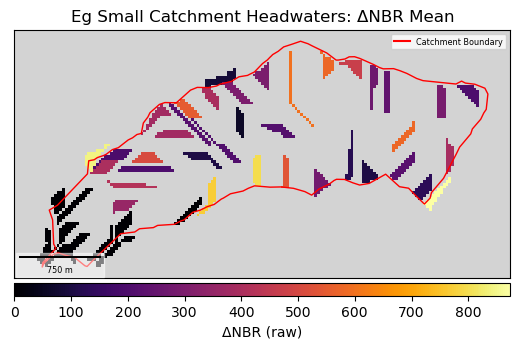

In [22]:
proj.plot_headwaters(example_catchment_name, colour_col='dNBR_mean', table=summary[example_catchment_name])